In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import os
import json
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/notjustauser/02-features/__results__.html
/kaggle/input/notebooks/notjustauser/02-features/smard_features.parquet
/kaggle/input/notebooks/notjustauser/02-features/__notebook__.ipynb
/kaggle/input/notebooks/notjustauser/02-features/__output__.json
/kaggle/input/notebooks/notjustauser/02-features/custom.css
/kaggle/input/notebooks/notjustauser/03-baselines/__results__.html
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_horizon_metrics.csv
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_predictions.parquet
/kaggle/input/notebooks/notjustauser/03-baselines/baseline_metrics.csv
/kaggle/input/notebooks/notjustauser/03-baselines/__notebook__.ipynb
/kaggle/input/notebooks/notjustauser/03-baselines/__output__.json
/kaggle/input/notebooks/notjustauser/03-baselines/split_config.json
/kaggle/input/notebooks/notjustauser/03-baselines/custom.css
/kaggle/input/notebooks/notjustauser/03-baselines/__results___files/__results___20_0.png
/kaggle/input/notebo

In [2]:
print("tensorflow version:",tf.__version__)
print("GPU Devices:",tf.config.list_physical_devices("GPU"))

tensorflow version: 2.20.0
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
SEED = 56

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
features_path = "/kaggle/input/notebooks/notjustauser/02-features/smard_features.parquet"

data = pd.read_parquet(features_path)
display(data.head())


,price_eur_mwh,load_actual_mwh,load_forecast_mwh,hour_sin,hour_cos,dow_sin,dow_cos,weekend,price_lag_1,price_lag_24,price_lag_48,price_lag_168,price_roll_mean_24,price_roll_std_24,price_roll_mean_168,price_roll_std_168,features_valid,forecast_load_available
timestamp,,,,,,,,,,,,,,,,,,
2022-08-31 19:00:00+00:00,677.26,54065.25,54673.50,-0.707107,0.707107,0.974928,-0.222521,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
2022-08-31 20:00:00+00:00,563.52,50545.00,50893.75,-0.500000,0.866025,0.974928,-0.222521,0,677.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
2022-08-31 21:00:00+00:00,532.51,46610.50,47281.75,-0.258819,0.965926,0.974928,-0.222521,0,563.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
2022-08-31 22:00:00+00:00,490.77,43779.50,45334.25,0.000000,1.000000,0.433884,-0.900969,0,532.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True
2022-08-31 23:00:00+00:00,484.36,42271.75,43953.25,0.258819,0.965926,0.433884,-0.900969,0,490.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True


In [5]:
split_path = "/kaggle/input/notebooks/notjustauser/03-baselines/split_config.json"

with open(split_path,"r") as f:
    split_config = json.load(f)

split_config
    

{'lookback_hours': 168,
 'forecast_horizon_hours': 24,
 'split_method': 'chronological_70_15_15',
 'train_first_target': '2022-09-07 19:00:00+00:00',
 'train_last_target': '2024-01-27 13:00:00+00:00',
 'validation_first_target': '2024-01-27 14:00:00+00:00',
 'validation_last_target': '2024-05-15 04:00:00+00:00',
 'test_first_target': '2024-05-15 05:00:00+00:00',
 'test_last_target': '2024-08-31 19:00:00+00:00'}

In [6]:
LOOKBACK =168
HORIZON = 24
data.columns.tolist()

['price_eur_mwh',
 'load_actual_mwh',
 'load_forecast_mwh',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'weekend',
 'price_lag_1',
 'price_lag_24',
 'price_lag_48',
 'price_lag_168',
 'price_roll_mean_24',
 'price_roll_std_24',
 'price_roll_mean_168',
 'price_roll_std_168',
 'features_valid',
 'forecast_load_available']

In [7]:
features_cols = ['load_actual_mwh',
 'load_forecast_mwh',
 'hour_sin',
 'hour_cos',
 'dow_sin',
 'dow_cos',
 'weekend',
 'price_lag_1',
 'price_lag_24',
 'price_lag_48',
 'price_lag_168',
 'price_roll_mean_24',
 'price_roll_std_24',
 'price_roll_mean_168',
 'price_roll_std_168',
 ]

target_cols = 'price_eur_mwh'
print("no.of features:",len(features_cols))

no.of features: 15


In [8]:
required = features_cols + [target_cols]

missing_cols = [c for c in required if c not in data.columns ]
print(missing_cols)

[]


In [9]:
train_last = pd.Timestamp(split_config["train_last_target"])
val_last = pd.Timestamp(split_config["validation_last_target"])
test_last = pd.Timestamp(split_config["test_last_target"])


In [10]:
train_frame = data.loc[data.index <= train_last].copy()
train_scaler_frame = train_frame[features_cols + [target_cols]].dropna()
print(len(train_scaler_frame))

12066


In [11]:
X_scaler = StandardScaler()
y_scaler = RobustScaler()
X_scaler.fit(train_scaler_frame[features_cols])
y_scaler.fit(train_scaler_frame[[target_cols]])

RobustScaler()

In [12]:
X_scaled = np.full((len(data), len(features_cols)),np.nan,dtype = np.float32)
valid_feature_rows = data[features_cols].notna().all(axis=1)

In [13]:
X_scaled[valid_feature_rows]=(X_scaler.transform(data.loc[valid_feature_rows,features_cols]).astype(np.float32))

In [14]:
y_scaled =(
    y_scaler
    .transform(data[[target_cols]])
    .ravel()
    .astype(np.float32)
) 

In [15]:
print(X_scaled.shape)
print(y_scaled.shape)

(17568, 15)
(17568,)


In [16]:
X_all = []
y_all = []
target_start_times = []

skipped_missing_X = 0
skipped_missing_y = 0

for start in range(
    LOOKBACK,
    len(data) - HORIZON + 1
):

    X_window = X_scaled[
        start - LOOKBACK : start
    ]

    y_window = y_scaled[
        start : start + HORIZON
    ]

    # Reject window if any historical feature is unavailable
    if np.isnan(X_window).any():
        skipped_missing_X += 1
        continue

    # Safety check
    if np.isnan(y_window).any():
        skipped_missing_y += 1
        continue

    if (
        X_window.shape
        != (LOOKBACK, len(features_cols))
    ):
        continue

    if y_window.shape != (HORIZON,):
        continue

    X_all.append(X_window.copy())
    y_all.append(y_window.copy())

    target_start_times.append(
        data.index[start]
    )

In [17]:
X_all = np.stack(X_all).astype(np.float32)
y_all = np.stack(y_all).astype(np.float32)

target_start_times = pd.DatetimeIndex(
    target_start_times
)

In [18]:
print("X shape:", X_all.shape)
print("y shape:", y_all.shape)

print("Skipped because of missing X:",
      skipped_missing_X)

print("Skipped because of missing y:",
      skipped_missing_y)

X shape: (16444, 168, 15)
y shape: (16444, 24)
Skipped because of missing X: 933
Skipped because of missing y: 0


In [19]:
train_first = pd.Timestamp(
    split_config["train_first_target"]
)

train_last = pd.Timestamp(
    split_config["train_last_target"]
)

val_first = pd.Timestamp(
    split_config["validation_first_target"]
)

val_last = pd.Timestamp(
    split_config["validation_last_target"]
)

test_first = pd.Timestamp(
    split_config["test_first_target"]
)

test_last = pd.Timestamp(
    split_config["test_last_target"]
)

In [20]:
train_mask = (
    (target_start_times >= train_first)
    &
    (target_start_times <= train_last)
)

val_mask = (
    (target_start_times >= val_first)
    &
    (target_start_times <= val_last)
)

test_mask = (
    (target_start_times >= test_first)
    &
    (target_start_times <= test_last)
)

In [21]:
X_train = X_all[train_mask]
y_train = y_all[train_mask]

X_val = X_all[val_mask]
y_val = y_all[val_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]

test_times = target_start_times[test_mask]

In [22]:
def build_lstm(input_shape, horizon=24):

    inp = keras.Input(
        shape=input_shape
    )

    x = layers.LSTM(
        64,
        dropout=0.2
    )(inp)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    out = layers.Dense(
        horizon
    )(x)

    model = keras.Model(
        inp,
        out
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss=keras.losses.Huber(),
        metrics=[
            keras.metrics.MeanAbsoluteError()
        ]
    )

    return model

In [23]:
model = build_lstm(
    input_shape=(
        X_train.shape[1],
        X_train.shape[2]
    ),
    horizon=HORIZON
)

I0000 00:00:1790491782.386606      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790491782.392855      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 168, 15)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,200 (102.34 KB)

 Trainable params: 26,200 (102.34 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
keras.losses.Huber()

<LossFunctionWrapper(<function huber at 0x78a887967740>, kwargs={'delta': 1.0})>

In [26]:
os.makedirs(
    "/kaggle/working/models",
    exist_ok=True
)

In [27]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5
    ),

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/models/best_lstm.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [28]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=125,
    batch_size=64,

    callbacks=callbacks,

    shuffle=False,

    verbose=1
)

Epoch 1/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.4906 - mean_absolute_error: 0.8126 - val_loss: 0.1393 - val_mean_absolute_error: 0.4094 - learning_rate: 0.0010
Epoch 2/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.3603 - mean_absolute_error: 0.6744 - val_loss: 0.1352 - val_mean_absolute_error: 0.4052 - learning_rate: 0.0010
Epoch 3/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3208 - mean_absolute_error: 0.6297 - val_loss: 0.1266 - val_mean_absolute_error: 0.3880 - learning_rate: 0.0010
Epoch 4/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.3031 - mean_absolute_error: 0.6072 - val_loss: 0.1172 - val_mean_absolute_error: 0.3696 - learning_rate: 0.0010
Epoch 5/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2905 - mean_absolute_error: 0.5908 - val_loss: 0.1145 - val_mean_absolute_error: 0.3689 - learning_rate: 0.0010
Epoch 6/125
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2845 - mean_absolute_error: 0.5829 - val_loss: 0.1135 - 

In [29]:
pred_scaled = model.predict(
    X_test,
    verbose=0
)

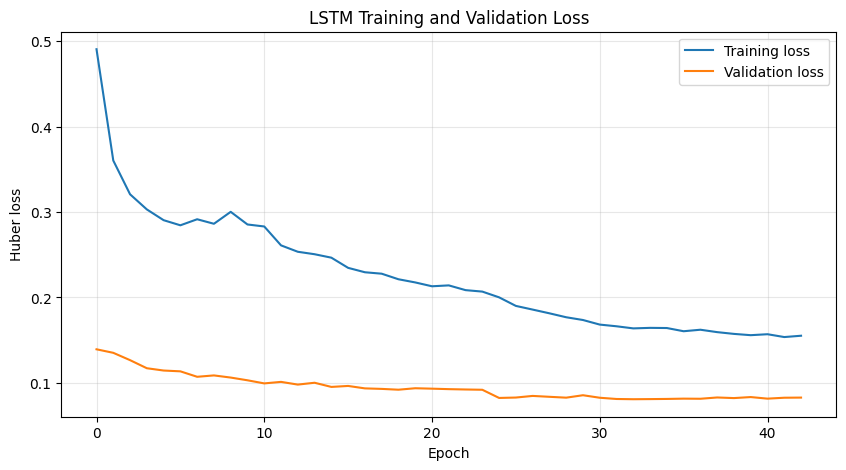

In [30]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
print(pred_scaled.shape)

(2607, 24)


In [32]:
pred = (
    y_scaler
    .inverse_transform(
        pred_scaled.reshape(-1, 1)
    )
    .reshape(pred_scaled.shape)
)

In [33]:
actual = (
    y_scaler
    .inverse_transform(
        y_test.reshape(-1, 1)
    )
    .reshape(y_test.shape)
)

In [34]:
def smape(y_true, y_pred, eps=1e-6):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return (
        100
        * np.mean(
            2 * np.abs(y_pred - y_true)
            /
            (
                np.abs(y_true)
                + np.abs(y_pred)
                + eps
            )
        )
    )

In [35]:
actual_flat = actual.ravel()
pred_flat = pred.ravel()

In [36]:
lstm_mae = mean_absolute_error(
    actual_flat,
    pred_flat
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_flat,
        pred_flat
    )
)

lstm_smape = smape(
    actual_flat,
    pred_flat
)

In [37]:
print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)
print("LSTM sMAPE:", lstm_smape)

LSTM MAE: 22.423799514770508
LSTM RMSE: 29.913783990933844
LSTM sMAPE: 46.865643


In [38]:
lstm_metrics = pd.DataFrame(
    [
        {
            "model": "LSTM",
            "MAE": lstm_mae,
            "RMSE": lstm_rmse,
            "sMAPE": lstm_smape
        }
    ]
)

display(lstm_metrics)

,model,MAE,RMSE,sMAPE
0,LSTM,22.4238,29.913784,46.865643


In [39]:
horizon_rows = []

for h in range(HORIZON):

    mae_h = mean_absolute_error(
        actual[:, h],
        pred[:, h]
    )

    horizon_rows.append(
        {
            "horizon": h + 1,
            "lstm_mae": mae_h
        }
    )

lstm_horizon_metrics = pd.DataFrame(
    horizon_rows
)

display(lstm_horizon_metrics)

,horizon,lstm_mae
0,1,19.123610
1,2,20.893997
2,3,22.209656
3,4,23.190784
4,5,23.449474
5,6,24.703655
6,7,24.299871
7,8,24.170551
8,9,23.999012
9,10,23.670925


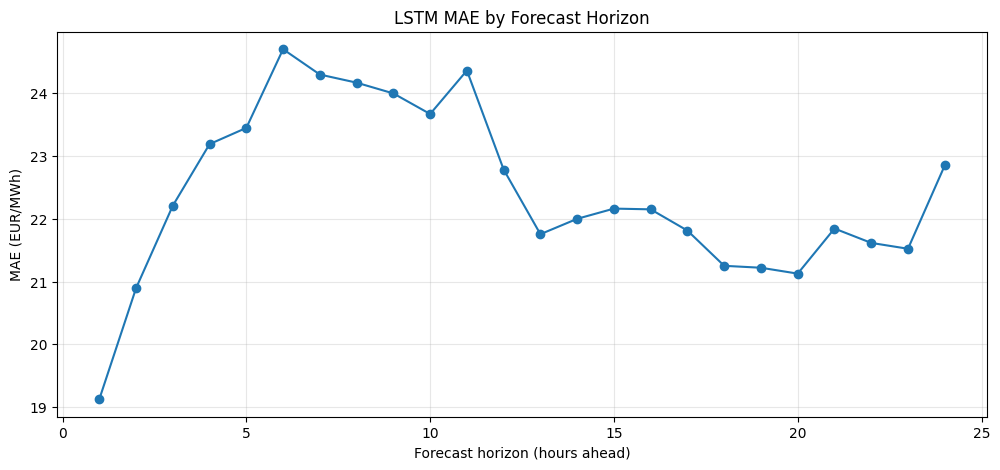

In [40]:
plt.figure(figsize=(12, 5))

plt.plot(
    lstm_horizon_metrics["horizon"],
    lstm_horizon_metrics["lstm_mae"],
    marker="o"
)

plt.xlabel("Forecast horizon (hours ahead)")
plt.ylabel("MAE (EUR/MWh)")
plt.title("LSTM MAE by Forecast Horizon")

plt.grid(alpha=0.3)
plt.show()

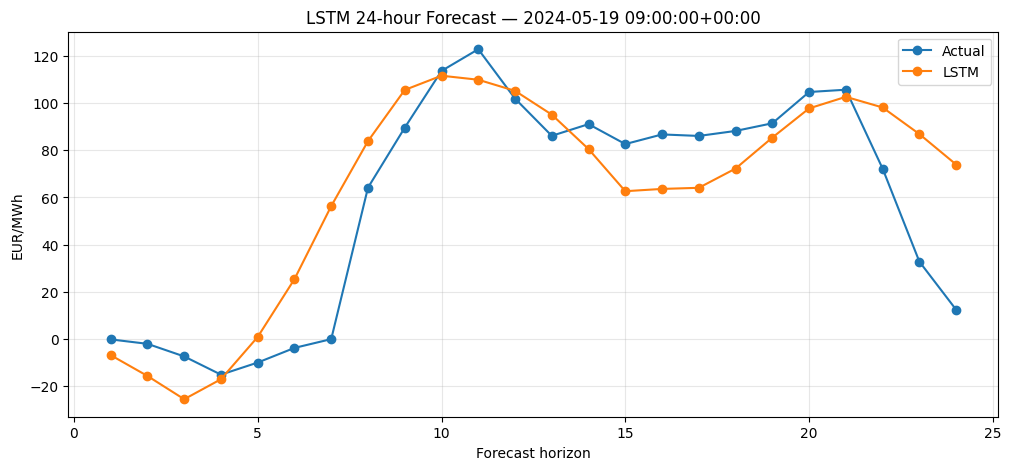

In [41]:
example = 100

hours = np.arange(1, 25)

plt.figure(figsize=(12, 5))

plt.plot(
    hours,
    actual[example],
    marker="o",
    label="Actual"
)

plt.plot(
    hours,
    pred[example],
    marker="o",
    label="LSTM"
)

plt.xlabel("Forecast horizon")
plt.ylabel("EUR/MWh")

plt.title(
    f"LSTM 24-hour Forecast — "
    f"{test_times[example]}"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [42]:
threshold = np.quantile(
    np.abs(actual_flat),
    0.95
)

extreme_mask = (
    np.abs(actual_flat)
    >= threshold
)

lstm_extreme_mae = mean_absolute_error(
    actual_flat[extreme_mask],
    pred_flat[extreme_mask]
)

print(
    "Extreme threshold:",
    threshold
)

print(
    "LSTM extreme MAE:",
    lstm_extreme_mae
)

Extreme threshold: 139.0
LSTM extreme MAE: 42.51289749145508


In [43]:
negative_mask = (
    actual_flat < 0
)

print(
    "Negative-price observations:",
    negative_mask.sum()
)

Negative-price observations: 6171


In [44]:
if negative_mask.sum() > 0:

    lstm_negative_mae = (
        mean_absolute_error(
            actual_flat[negative_mask],
            pred_flat[negative_mask]
        )
    )

    print(
        "LSTM negative-price MAE:",
        lstm_negative_mae
    )

LSTM negative-price MAE: 40.50691223144531


In [45]:
records = []

for i in range(len(actual)):

    for h in range(HORIZON):

        records.append(
            {
                "forecast_start":
                    test_times[i],

                "horizon":
                    h + 1,

                "actual":
                    actual[i, h],

                "lstm":
                    pred[i, h]
            }
        )

In [46]:
lstm_predictions = pd.DataFrame(
    records
)

display(lstm_predictions.head())

,forecast_start,horizon,actual,lstm
0,2024-05-15 05:00:00+00:00,1,88.160004,108.561241
1,2024-05-15 05:00:00+00:00,2,84.449997,111.642334
2,2024-05-15 05:00:00+00:00,3,48.420002,98.802559
3,2024-05-15 05:00:00+00:00,4,7.360003,73.431206
4,2024-05-15 05:00:00+00:00,5,-0.080000,58.398640


In [47]:
lstm_predictions.to_parquet(
    "/kaggle/working/lstm_predictions.parquet",
    index=False
)

In [48]:
lstm_metrics.to_csv(
    "/kaggle/working/lstm_metrics.csv",
    index=False
)

In [49]:
lstm_horizon_metrics.to_csv(
    "/kaggle/working/lstm_horizon_metrics.csv",
    index=False
)

In [50]:
import joblib

joblib.dump(
    X_scaler,
    "/kaggle/working/X_scaler.joblib"
)

joblib.dump(
    y_scaler,
    "/kaggle/working/y_scaler.joblib"
)

['/kaggle/working/y_scaler.joblib']

In [51]:
model_config = {

    "model": "LSTM",

    "lookback": LOOKBACK,
    "horizon": HORIZON,

    "features_cols": features_cols,

    "lstm_units": 64,

    "dropout": 0.2,

    "dense_units": 64,

    "optimizer": "Adam",

    "learning_rate": 1e-3,

    "loss": "Huber",

    "batch_size": 64,

    "max_epochs": 125,

    "seed": SEED
}

In [52]:
with open(
    "/kaggle/working/lstm_config.json",
    "w"
) as f:

    json.dump(
        model_config,
        f,
        indent=4
    )